In [1]:
import xarray as xr
import numpy as np
import gsw
from matplotlib import cm
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
from matplotlib.animation import FuncAnimation
from matplotlib import animation
import ffmpeg
import pylab as pl
import pandas as pd
from math import radians, cos, sin
from matplotlib.gridspec import GridSpec
import scipy.interpolate as sciint
from mpl_toolkits.axes_grid1 import make_axes_locatable

In [28]:
project='realBathy'
ed='run7/'

directory='/Users/ameliameggo/Proyecto/Codigo/NGC/'+ str(project)
dataloc=str(directory)+ '/' + str(ed)
location= str(directory) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'

#location='/home/amelia/NGC/'+ str(project) + '/Files/' + str(ed) #'/Users/ameliaking/Proyecto/Codigo/Idealizada/ChangeDim/'


var='dynDiag'
ds=xr.open_dataset(str(location) +  str(var) + '.nc')


#varS='surfDiag40'

#dsS=xr.open_dataset(str(location) +  str(varS) + '.nc')

varG='grid'

dsG=xr.open_dataset(str(location) +  str(varG) + '.nc')


#Take them minus 1 and 2 to skip the boundary
ny=len(dsG.Y)
nx=len(dsG.X) 
nz=len(dsG.Z)
nt=len(ds.T) 

if project=='twoBumps':
    umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]+1
    umbral2=np.where(dsG.Depth[int(ny/2):,20].values==np.min(dsG.Depth[int(ny/2):,20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):,20].values==600)[0])/2)]+int(ny/2)+1

    umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]<np.max(dsG.Depth[:int(ny/2),20]))[0][-1]
    umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)
if project=='realBathy':
    umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]+1
    umbral2=np.where(dsG.Depth[int(ny/2):,20].values==np.min(dsG.Depth[int(ny/2):,20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):,20].values==600)[0])/2)]+int(ny/2)+1

    umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]<np.max(dsG.Depth[:int(ny/2),20]))[0][-1]
    umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)
else:
    umbral=np.where(dsG.Depth[:,20].values==np.min(dsG.Depth[:,20].values))[0][int(len(np.where(dsG.Depth[:,20].values==np.min(dsG.Depth[:,20].values))[0])/2)]
    umbralEnd=np.where(dsG.Depth[:,20]<np.max(dsG.Depth[:,20]))[0][-1]

hFacC = dsG.HFacC

hfa = np.ma.masked_values(hFacC, 0)
mask = np.ma.getmask(hfa)

hFacW = dsG.HFacW

hfaW = np.ma.masked_values(hFacW, 0)
maskw = np.ma.getmask(hfaW)

hFacS = dsG.HFacS

hfaS = np.ma.masked_values(hFacS, 0)
masks = np.ma.getmask(hfaS)

#info=pd.read_csv(str(dataloc) + 'data',sep='/n')
#parameters=['viscAh','viscAr','diffKhT','diffKrT']


if project == '2Dsill':
    OB=1
    OBend=-1
elif project =='2DsillOB':
    OBp=1
    OBendp=-1
    OB=21
    OBend=-1
elif project =='OpenNorth' or project =='Orlanski':
    OBp=1
    OBendp=-1
    OB=10
    OBend=-10
    OBx=1
    OBendx=-1
else:
    OBp=1
    OBendp=-1
    OB=20
    OBend=-20
    OBx=1
    OBendx=-1

In [33]:
start=np.where(ds.T/(60*60*24*360)>=50)[0][0]
end =np.where(ds.T/(60*60*24*360)<=51)[0][-1] # np.where(np.isnan(ds.WVEL[:,10,10,5])==False)[0][-1] #

In [37]:
umbral1=np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0][int(len(np.where(dsG.Depth[:int(ny/2),20].values==np.min(dsG.Depth[:int(ny/2),20].values))[0])/2)]+1
umbral2=np.where(dsG.Depth[int(ny/2):-int(ny/4),20].values==np.min(dsG.Depth[int(ny/2):-int(ny/4),20].values))[0][int(len(np.where(dsG.Depth[int(ny/2):-int(ny/4),20].values==600)[0])/2)]+int(ny/2)+1
umbral3=np.where(dsG.Depth[-int(ny/4):,20].values==np.min(dsG.Depth[-int(ny/4):,20].values))[0][-1]+(len(dsG.Depth[:,0])-int(ny/4))-7


umbralEnd1=np.where(dsG.Depth[:int(ny/2),20]==np.max(dsG.Depth[:int(ny/2),20]))[0][0]
umbralEnd2=np.where(dsG.Depth[int(ny/2):,20]<np.max(dsG.Depth[int(ny/2):,20]))[0][-1]+int(ny/2)

In [38]:
depindUmb=np.where(dsG.Z>=-600)[0][-2]
depind800=np.where(dsG.Z<-800)[0][0]-1
umbralStart2=np.where(dsG.Depth[umbralEnd1:,20]<np.max(dsG.Depth))[0][0]+umbralEnd1


In [39]:
nz=80     # number of gridpoints in z-direction
nt=12 #nt=10  #for 3 years with timestep 60 s
dx=0.5
dz=16

OB=15

x=np.arange(0,nx*dx,dx)
z=np.arange(0,nz*dz,dz)
indz600=len(z[z<600])
indzSill=len(z[z<np.min(dsG.Depth.values[dsG.Depth.values!=0])])
tempS=np.zeros(nz)
tempS[:indzSill]=np.arange(16,8,(8-16)/indzSill)
tempS[indzSill-1:indz600]=np.arange(tempS[indzSill-1],7,(7-tempS[indzSill-1])/(len(tempS[indzSill-1:indz600])))
tempS[indz600-1:]=np.arange(tempS[indz600-1],5,(5.02-tempS[indz600-1])/(len(tempS[indz600:])))
tempBoS=np.tile(np.tile(tempS,(nx,1)).T,(nt,1,1)).T

In [178]:
umb=umbral1
umbEnd=umbralEnd1
depth=np.zeros((3,len(dsG.X[1:-1])))
density1=np.zeros((3,len(dsG.X[1:-1])))
density2=np.zeros((3,len(dsG.X[1:-1])))
avvel=np.zeros((3,len(dsG.X[1:-1])))
avveltop=np.zeros((3,len(dsG.X[1:-1])))
transp=np.zeros((3,len(dsG.X[1:-1])))
MeridRhoTransp1=np.zeros((3,len(dsG.X[1:-1])))
densav=np.zeros(3)
denstop=np.zeros(3)
start=len(ds.T)-4
k=0
for p in [umbral1,umbral2,umbral3]:
    for i in np.arange(1,len(dsG.X)-1,1):
        Area=(dsG.drF.values[:]*dsG.HFacS[:,p,i].values)*dsG.dxG.values[p,i]
        if np.any(np.mean(ds.VVEL[start:len(ds.T),:,p,i],axis=0)<0)==False:
            inddep=np.argmax(np.mean(ds.VVEL[start:len(ds.T),:,p,i].values,axis=0))-6
            depth[k,i-1]=dsG.Z[inddep]
            avvel[k,i-1]=np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:len(ds.T),:,p,i],axis=0),mask=masks[:,p,i]))
        elif np.any(np.mean(ds.VVEL[start:len(ds.T),:,p,i],axis=0)>0)==False:
            transp[k,i-1]=0
            MeridRhoTransp1[k,i-1]=0
        else:
            if p==umbral1:
                inddep=np.where(np.mean(ds.VVEL[start:len(ds.T),:,p,i],axis=0)<0)[0][-1]+1
            elif p==umbral3:
                inddep=np.where(np.mean(ds.VVEL[start:len(ds.T),:,p,i],axis=0)>0)[0][-1]+1
            depth[k,i-1]=dsG.Z[inddep]
            avvel[k,i-1]=np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:len(ds.T),inddep:,p,i],axis=0),mask=masks[inddep:,p,i]))
            avveltop[k,i-1]=np.mean(np.ma.masked_array(np.mean(ds.VVEL[start:len(ds.T),:inddep,p,i],axis=0),mask=masks[:inddep,p,i]))
            maxdep=np.min(np.ma.masked_array(dsG.Z.values,mask=mask[:,p,i]))
            vel=np.ma.masked_array(np.mean(ds.VVEL[start:len(ds.T),inddep:,p,i],axis=0),mask=masks[inddep:,p,i])
            transp[k,i-1]=np.sum(Area[inddep:]*vel)*1e-6
            densav[k]=np.mean(np.ma.masked_array(np.mean(ds.RHOAnoma.values,axis=0)+1026.35,mask=mask)[inddep:,p,:])
            denstop[k]=np.mean(np.ma.masked_array(np.mean(ds.RHOAnoma.values,axis=0)+1026.35,mask=mask)[:inddep,p,:])
    k=k+1


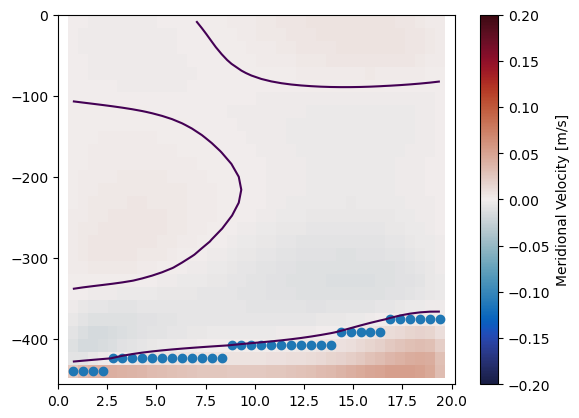

In [109]:
fig,ax=plt.subplots()
p=0
inds=[umbral1,umbral2,umbral3]#np.arange(umb,umbEnd,1)
cax=ax.pcolormesh(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VVEL[start:,:,inds[p],:],axis=0),mask=masks[:,inds[p],:]),vmin=-0.2,vmax=0.2,cmap=cmocean.cm.balance)
ymax=dsG.Z.values[masks[:,umbral1,5]==True][0]
ax.set_ylim((ymax,0))
ax.scatter(dsG.X[1:-1]/1000,depth[p])
cbar=plt.colorbar(cax)
cbar.set_label('Meridional Velocity [m/s]')

#ax.set(ylabel='Depth [m]',title='First sill')

ax.contour(dsG.X/1000,dsG.Z,np.ma.masked_array(np.mean(ds.VVEL[start:,:,inds[p],:],axis=0),mask=masks[:,inds[p],:]),levels=[0])



##### Brunt väisälä frequency

In [51]:
def BV_frequency(rho_anom, z, rho0=1026.35, g=9.82):
    """
    Compute Brunt–Väisälä frequency squared (N^2) and N.

    Parameters
    ----------
    rho_anom : array_like
        Density anomaly array [kg/m^3]
        (e.g. sigma or rho - rho0)
    z : array_like
        Depth or vertical coordinate [m]
        Must have same length as rho_anom.
        Convention here: z positive upward.
        For ocean depth positive downward, see note below.
    rho0 : float
        Background/reference density [kg/m^3]
    g : float
        Gravity [m/s^2]

    Returns
    -------
    N2 : ndarray
        Brunt–Väisälä frequency squared [s^-2]
    N : ndarray
        Brunt–Väisälä frequency [s^-1]
    """

    rho_anom = np.asarray(rho_anom)
    z = np.asarray(z)

    # Total density
    rho = rho0 + rho_anom

    # Vertical density gradient
    
    drho_dz = np.gradient(rho, z,axis=0)

    # Brunt–Väisälä frequency squared
    N2 = -(g / rho0) * drho_dz

    # Avoid sqrt of negative values
    N = np.sqrt(np.maximum(N2, 0))

    return N2, N

In [170]:
rhoanom=np.ma.masked_array(np.mean(ds.RHOAnoma.values,axis=0),mask=mask)
N2, N = BV_frequency(rhoanom, dsG.Z.values)


(0.0, 5e-05)

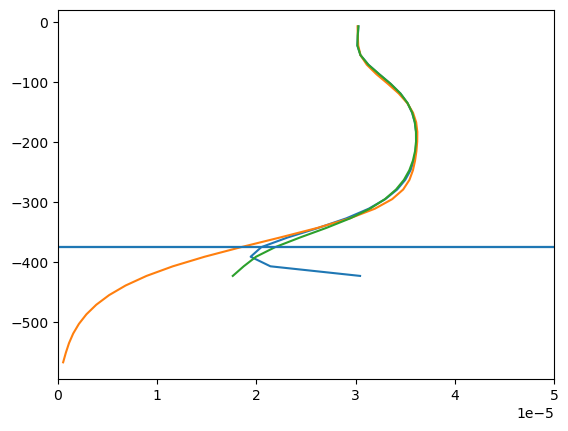

In [171]:
N2umb1=np.mean(N2[:,umbral1,:],axis=1)[mask[:,umbral1,10]==False][:-1]
Zumb1=dsG.Z[mask[:,umbral1,10]==False][:-1].values

N2umb2=np.mean(N2[:,umbral2,:],axis=1)[mask[:,umbral2,10]==False][:-1]
Zumb2=dsG.Z[mask[:,umbral2,10]==False][:-1].values

N2umb3=np.mean(N2[:,umbral3,:],axis=1)[mask[:,umbral3,10]==False][:-1]
Zumb3=dsG.Z[mask[:,umbral3,10]==False][:-1].values

plt.plot(N2umb1,Zumb1)
plt.plot(N2umb2,Zumb2)
plt.plot(N2umb3,Zumb3)

Zindumb1=np.where(Zumb1==np.max(depth[0]))[0][0]
Zindumb2=np.where(Zumb2==np.max(depth[1]))[0][0]
Zindumb3=np.where(Zumb2==np.max(depth[2]))[0][0]

plt.axhline(Zumb1[Zindumb1])
plt.axhline(Zumb2[Zindumb2])
plt.axhline(Zumb3[Zindumb3])
plt.xlim((0,0.00005))

##### Calculate phase velocity of internal waves using n2. $Cn = NH/\pi$
##### Calculate Froude number $Fr=U/(NH/\pi)$ using L as the hydraulic depth (crosssectional area/free surface width)


In [172]:
U1=np.mean(avvel[0])
U2=np.mean(avvel[1])
U3=np.mean(avvel[2])

Numb1=np.mean(np.sqrt(N2umb1[Zindumb1:]))
Numb2=np.mean(np.sqrt(N2umb2[Zindumb2:]))
Numb3=np.mean(np.sqrt(N2umb3[Zindumb3:]))


In [173]:
Cn=(N1*H)/np.pi
U1/Cn

np.float64(0.28345080234750064)

##### Calculate Froude number $Fr=U/\sqrt{g'H}$ using H as the thickness of the overflow

In [174]:
rho0=1026.35
g=9.82
gprime=g*((densav-denstop)/rho0)

In [175]:
U=np.mean(avvel,axis=1)
H=np.max(depth)-Zumb1[-1]
U/np.sqrt(gprime*H)

array([ 0.03517013, -0.00187775, -0.02508136])

##### Rossby radius of deformation

In [177]:
f=6.691298637438928e-05
np.sqrt(gprime*H)/f

array([8778.85207448, 8853.63665321, 8490.43231759])

##### Calculate Richardson number $Ri=-g \frac{d\rho}{dz} / \rho (\frac{dv}{dz})^{2} $ using L as the hydraulic depth (crosssectional area/free surface width)

In [182]:
dU=(np.mean(avvel[0])-np.mean(avveltop[0]))
dz=np.mean(Zumb1[Zindumb1:]) - np.mean(Zumb1[:Zindumb1])

masked_array(data=[0.004372043535113335, 0.01604228839278221,
                   0.030125124379992485, 0.04244004189968109,
                   0.04536959528923035, --, --, --, --, --, --, --, --,
                   --, --, --, --, --, --, --, --, --, --, --, --, --, --,
                   --, --, --, --, --, --, --, --, --, --, --, --, --, --,
                   --, --, --, --, --, --, --, --, --, --, --, --, --, --,
                   --, --],
             mask=[False, False, False, False, False,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True,  True,  True,  True,  True,  True,  True,  True,
                    True],

In [193]:
U=np.ma.masked_array(np.mean(ds.VVEL[start:len(ds.T),:,umbral1,-3],axis=0),mask=masks[:,umbral1,-3])
dU_dz = np.gradient(U, dsG.Z.values,axis=0)

In [197]:
dU_dz[:27]

masked_array(data=[-5.632371176034212e-05, -3.1928037060424685e-05,
                   2.509242040105164e-05, 8.334768790518865e-05,
                   0.00011221162276342511, 9.897854761220515e-05,
                   5.888556916033849e-05, 1.604795761522837e-05,
                   -1.2555588909890503e-05, -2.2212894691620022e-05,
                   -1.7779297195374966e-05, -7.642061973456293e-06,
                   1.8874488887377083e-06, 9.001021680887789e-06,
                   1.5530051314271986e-05, 2.446120197419077e-05,
                   3.7533223803620785e-05, 5.3597454098053277e-05,
                   6.710781599394977e-05, 6.489246152341366e-05,
                   2.0501756807789207e-05, -0.0001030876737786457,
                   -0.00032280670711770654, -0.0005927043384872377,
                   -0.0008047837764024734, -0.00082492979709059,
                   -0.0004763897159136832],
             mask=[False, False, False, False, False, False, False, False,
                

In [199]:

Ri=N2umb1/(dU_dz[:27]**2)

In [20]:
deltaZ=999.8*((np.max(dV))**2)/(4*g*np.nanmin(dRHO))

In [200]:
Ri

masked_array(data=[9548.152153890895, 29649.301244676448,
                   47932.58100684793, 4389.443246367872,
                   2485.329169032398, 3307.104555746175,
                   9675.387690917622, 134058.17180634083,
                   223498.946264025, 72346.20494082796,
                   113789.84718573903, 618136.2172426117,
                   10139029.331681991, 444922.6861668072,
                   148721.36783997476, 59394.42837283171,
                   24847.01839207568, 11902.720562321287,
                   7327.340596971493, 7438.774627656859,
                   69168.27828427762, 2469.486343752695,
                   222.09135884534516, 58.36372369509454,
                   29.991109242029594, 31.46988887527793,
                   134.18766504311142],
             mask=[False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, False, False,
                   False, False, False, False, False, False, F

##### Potential vorticity

In [203]:
pv=(N2*f)/g

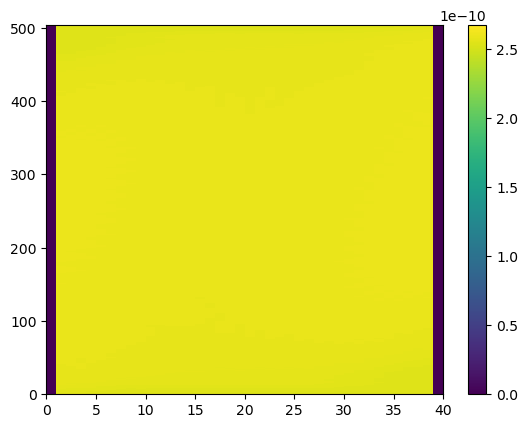

In [205]:
plt.pcolormesh(pv[10,:,:],vmin=)
plt.colorbar()